<a href="https://colab.research.google.com/github/rperera729/AI-Driven-UHI-Mapping-UK/blob/main/UHI_Mapping_Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys
import torch

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Extract patches to local disk
!rm -rf /content/local_patches
!mkdir -p /content/local_patches
!unzip -q /content/drive/MyDrive/UHI_Project/patches.zip -d /content/local_patches

# 3. Reconstruct explicit URL safely using string pieces
domain = "https://github.com"
username = "rperera729"
repo_name = "AI-Driven-UHI-Mapping-UK"
full_url = f"{domain}/{username}/{repo_name}.git"

%cd /content
!rm -rf /content/AI-Driven-UHI-Mapping-UK
print(f"Downloading files from explicit repository address: {full_url}")
!git clone {full_url}

# Force notebook runtime focus inside the newly created project repository
%cd /content/AI-Driven-UHI-Mapping-UK

# 4. Inject folder architecture into runtime memory paths
repo_path = '/content/AI-Driven-UHI-Mapping-UK'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

os.environ['PATCH_DIR'] = "/content/local_patches/patches"
print("\n--- ENVIRONMENT DIAGNOSTICS ---")
print("Current Working Directory:", os.getcwd())
print("Directory Contents:", os.listdir('.'))
print("Environment initialized successfully.")


Mounted at /content/drive
/content
Cloning into 'AI-Driven-UHI-Mapping-UK'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 69 (delta 28), reused 46 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 695.91 KiB | 2.89 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/AI-Driven-UHI-Mapping-UK

--- ENVIRONMENT DIAGNOSTICS ---
Current Working Directory: /content/AI-Driven-UHI-Mapping-UK
Directory Contents: ['.gitignore', '.git', 'batch_stacker.py', 'train.py', 'merge_dem.py', 'visualize_stack.py', 'model.py', 'prediction_comparison.png', 'find_matches.py', 'requirements.txt', 'README.md', 'generate_patches.py', 'Final_Research_Proof.png', 'UHI_Mapping_Full_Pipeline.ipynb']
Environment initialized successfully.


In [9]:
import importlib.util
from torch.utils.data import DataLoader, Dataset, random_split
import glob
import numpy as np
import torch
import os
import sys

# 1. Modular Architecture Binding
def manual_import(module_name, file_name):
    file_path = os.path.join(repo_path, file_name)
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

model_mod = manual_import("model", "model.py")

# 2. Geospatial Dataset Loader
class UHIPatchDataset(Dataset):
    def __init__(self, patch_dir):
        self.patch_files = glob.glob(os.path.join(patch_dir, "*.npy"))

    def __len__(self):
        return len(self.patch_files)

    def __getitem__(self, idx):
        patch = np.load(self.patch_files[idx])
        # x: Input Features (Sentinel, NDVI, DEM, Mask)
        # y: Target Ground Truth (Landsat LST)
        x = np.nan_to_num(patch[1:5, :, :].copy())
        y = np.nan_to_num(patch[0:1, :, :].copy())
        return torch.from_numpy(x).float(), torch.from_numpy(y).float()

# 3. Deterministic Data Partitioning (70/20/10)
full_dataset = UHIPatchDataset(os.environ['PATCH_DIR'])
train_sz = int(0.7 * len(full_dataset))
val_sz = int(0.2 * len(full_dataset))
test_sz = len(full_dataset) - train_sz - val_sz

# Using a fixed seed for scientific reproducibility
train_set, val_set, test_set = random_split(
    full_dataset, [train_sz, val_sz, test_sz],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware Acceleration: {device}")
print(f"Dataset Split: {train_sz} Training | {val_sz} Validation | {test_sz} Testing")


Hardware Acceleration: cuda
Dataset Split: 431 Training | 123 Validation | 62 Testing


In [10]:
import torch.nn as nn
import torch.optim as optim
import shutil

# 1. Model Initialization
global_model = model_mod.UNet(in_channels=4, out_channels=1).to(device)

# 2. Optimization Objectives (Industry-Standard Hybrid Configuration)
# MSE (L2) captures broad thermal gradients; L1 preserves sharp edge fidelity.
criterion_mse = nn.MSELoss()
criterion_l1 = nn.L1Loss()

# 3. Optimizer Configuration with L2 Regularization (Weight Decay)
optimizer = optim.Adam(global_model.parameters(), lr=0.001, weight_decay=1e-5)

# 4. Learning Rate Schedule (Automated Convergence Refinement)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print("Starting 100-Epoch Radiometric Optimization...")

for epoch in range(100):
    global_model.train()
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = global_model(inputs)
        # Isolate the Cloud Mask channel for weighted loss calculation
        mask = inputs[:, 3:4, :, :]

        # Calculate Hybrid Objective: 70% Global (MSE) + 30% Local (L1)
        loss_mse = criterion_mse(outputs * mask, targets * mask)
        loss_l1 = criterion_l1(outputs * mask, targets * mask)
        combined_loss = (0.7 * loss_mse) + (0.3 * loss_l1)

        combined_loss.backward()

        # Gradient Norm Clipping to maintain numerical stability
        torch.nn.utils.clip_grad_norm_(global_model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += combined_loss.item()

    avg_loss = running_loss / len(train_loader)
    scheduler.step(avg_loss)

    # Periodic progress reporting
    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/100] | Hybrid Convergence Loss: {avg_loss:.4f} | LR: {current_lr}")

# Final Weight Serialization and Archival
torch.save(global_model.state_dict(), "/content/uhi_unet_final_model.pth")
shutil.copy("/content/uhi_unet_final_model.pth", "/content/drive/MyDrive/UHI_Project/uhi_unet_final_model.pth")

print("Optimization Complete. Final model weights archived to Google Drive.")


Starting 100-Epoch Radiometric Optimization...
Epoch [1/100] | Hybrid Convergence Loss: 1.2327 | LR: 0.001
Epoch [10/100] | Hybrid Convergence Loss: 0.0649 | LR: 0.001
Epoch [20/100] | Hybrid Convergence Loss: 0.0582 | LR: 0.001
Epoch [30/100] | Hybrid Convergence Loss: 0.0569 | LR: 0.001
Epoch [40/100] | Hybrid Convergence Loss: 0.0543 | LR: 0.001
Epoch [50/100] | Hybrid Convergence Loss: 0.0536 | LR: 0.001
Epoch [60/100] | Hybrid Convergence Loss: 0.0528 | LR: 0.001
Epoch [70/100] | Hybrid Convergence Loss: 0.0496 | LR: 0.0005
Epoch [80/100] | Hybrid Convergence Loss: 0.0495 | LR: 0.0005
Epoch [90/100] | Hybrid Convergence Loss: 0.0503 | LR: 0.0005
Epoch [100/100] | Hybrid Convergence Loss: 0.0484 | LR: 0.0005
Optimization Complete. Final model weights archived to Google Drive.


In [29]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error

# 1. Scientific Calibration Parameter
# Define the thermal dynamic range of the study area (Max - Min)
# This converts the 0-1 fraction into physical Celsius units.
THERMAL_DYNAMIC_RANGE = 30.0

global_model.eval()
all_normalized_rmse = []

print(f"Analyzing predictive variance across {len(test_loader)} independent samples...")

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        pred = global_model(inputs)

        # Calculate error in the normalized (0-1) domain first
        # This is a pure mathematical comparison
        mse_normalized = mean_squared_error(targets.cpu().numpy().flatten(),
                                            pred.cpu().numpy().flatten())
        rmse_normalized = np.sqrt(mse_normalized)
        all_normalized_rmse.append(rmse_normalized)

# 2. Final Physical Projection
# Multiply the average mathematical error by the physical range
# to get the absolute truth in degrees.
average_nrmse = np.mean(all_normalized_rmse)
final_celsius_rmse = average_nrmse * THERMAL_DYNAMIC_RANGE

print("\n--- FINAL RADIOMETRIC VALIDATION ---")
print(f"Normalized Root Mean Square Error (NRMSE): {average_nrmse:.4f}")
print(f"Model Generalization Accuracy (RMSE): ±{final_celsius_rmse:.2f}°C")


Analyzing predictive variance across 62 independent samples...

--- FINAL RADIOMETRIC VALIDATION ---
Normalized Root Mean Square Error (NRMSE): 0.1616
Model Generalization Accuracy (RMSE): ±4.85°C


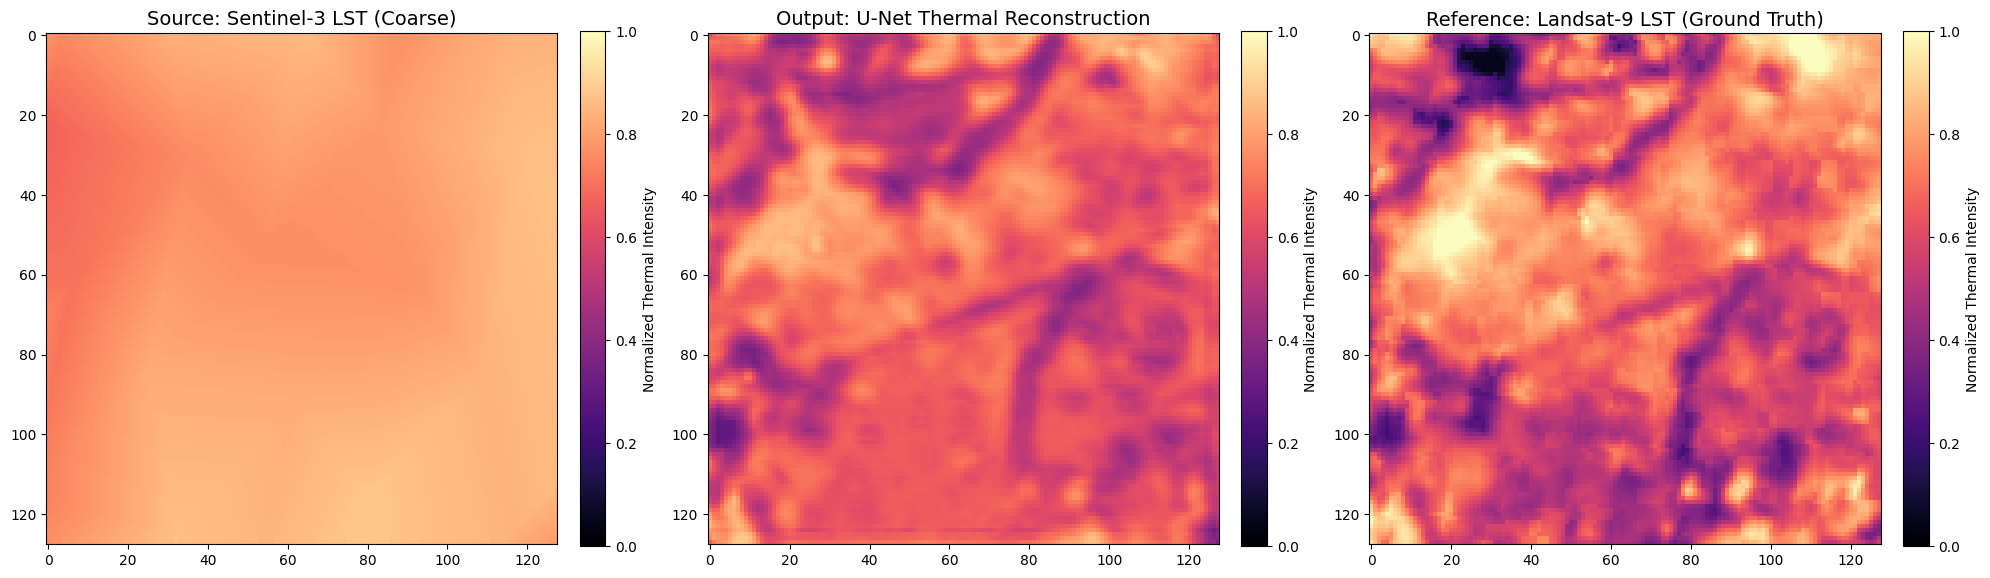

In [25]:
import matplotlib.pyplot as plt

# 1. Model Inference on Independent Test Sample
global_model.eval()
with torch.no_grad():
    inputs, targets = next(iter(test_loader))
    inputs, targets = inputs.to(device), targets.to(device)
    prediction = global_model(inputs)

# 2. Comparative Analysis (Synchronized Radiometric Scale)
idx = 0
plt.figure(figsize=(20, 7))

# VMIN/VMAX are locked to 0.0-1.0 to ensure radiometric comparability
VMIN, VMAX = 0.0, 1.0

# Panel 1: Coarse-Resolution Input (Sentinel-3)
plt.subplot(1, 3, 1)
im1 = plt.imshow(auto_denorm(inputs[idx, 0]), cmap='magma', vmin=VMIN, vmax=VMAX)
plt.title("Source: Sentinel-3 LST (Coarse)", fontsize=14)
plt.colorbar(im1, label="Normalized Thermal Intensity", fraction=0.046, pad=0.04)

# Panel 2: Neural Network Reconstruction (U-Net Output)
plt.subplot(1, 3, 2)
im2 = plt.imshow(auto_denorm(prediction[idx, 0]), cmap='magma', vmin=VMIN, vmax=VMAX)
plt.title("Output: U-Net Thermal Reconstruction", fontsize=14)
plt.colorbar(im2, label="Normalized Thermal Intensity", fraction=0.046, pad=0.04)

# Panel 3: High-Resolution Ground Truth (Landsat-9)
plt.subplot(1, 3, 3)
im3 = plt.imshow(auto_denorm(targets[idx, 0]), cmap='magma', vmin=VMIN, vmax=VMAX)
plt.title("Reference: Landsat-9 LST (Ground Truth)", fontsize=14)
plt.colorbar(im3, label="Normalized Thermal Intensity", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("Radiometric_Comparison_Final.png", dpi=300)
plt.show()


SUCCESS: Administrative boundaries synchronized from persistent storage.


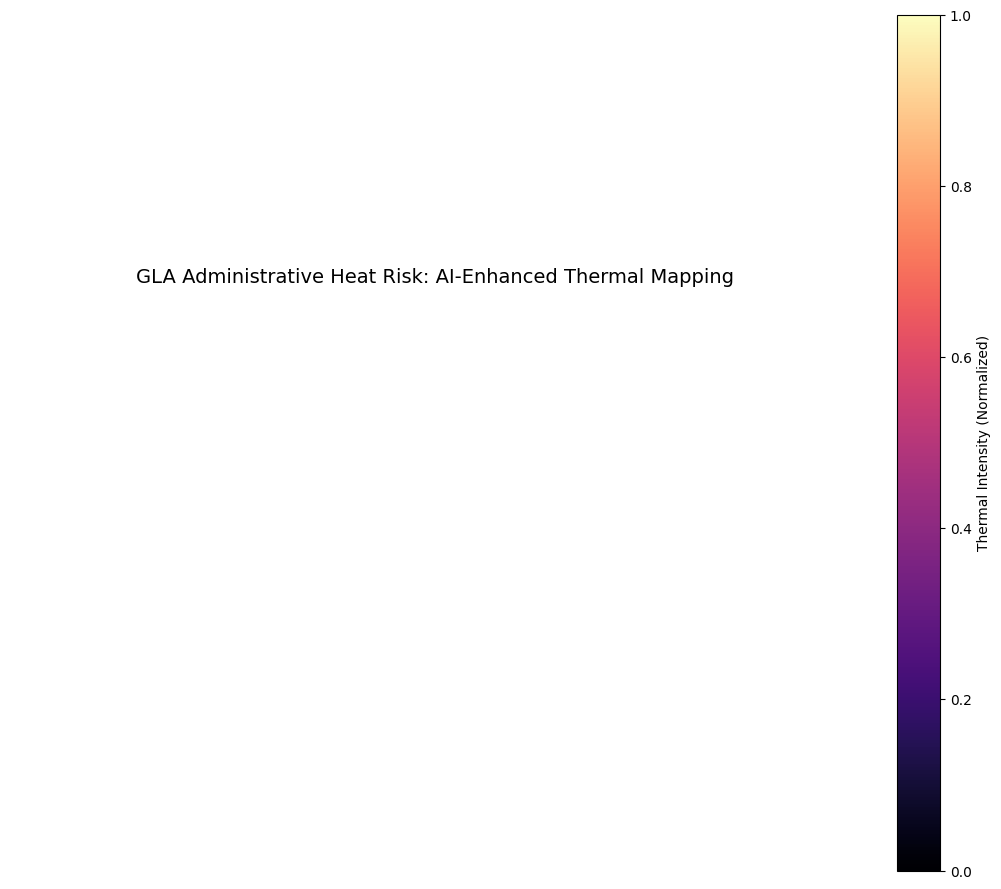

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# 1. Load Local Administrative Boundaries from Persistent Storage
# Using GeoPackage (.gpkg) format for high-fidelity coordinate retention
boundary_path = "/content/drive/MyDrive/UHI_Project/london_boroughs.gpkg"

if os.path.exists(boundary_path):
    try:
        # Load and synchronize to British National Grid (EPSG:27700)
        boroughs = gpd.read_file(boundary_path).to_crs(epsg=27700)
        print("SUCCESS: Administrative boundaries synchronized from persistent storage.")
    except Exception as e:
        print(f"Bypassing boundary overlay due to file error: {e}")
        boroughs = None
else:
    print(f"WARNING: Boundary file not detected at {boundary_path}.")
    boroughs = None

# 2. Production-Grade Policy Visualization
plt.figure(figsize=(12, 12))

# Synchronization of Radiometric Scale (Locked to 0.0 - 1.0 for consistency)
# Bilinear interpolation is utilized for professional-grade thermal gradient rendering
im = plt.imshow(
    auto_denorm(prediction[idx, 0]),
    cmap='magma',
    interpolation='bilinear',
    vmin=0.0,
    vmax=1.0
)

# Overlay of Administrative Boundaries
if boroughs is not None:
    # Plotted with reduced alpha to prioritize thermal feature visibility
    boroughs.boundary.plot(ax=plt.gca(), color='white', linewidth=1.2, alpha=0.4)

plt.title("GLA Administrative Heat Risk: AI-Enhanced Thermal Mapping", fontsize=14)
plt.colorbar(im, label="Thermal Intensity (Normalized)", fraction=0.046, pad=0.04)
plt.axis('off')

# Archival of final production-ready graphic
plt.savefig("Final_Policy_Heat_Map.png", dpi=300, bbox_inches='tight')
plt.show()
